# 上市公司财务绩效分析

本 Notebook 基于 Python 与 Yahoo Finance 数据，对上市公司股票价格进行清洗、分析与可视化，输出结论。

## 1. 环境准备

如果当前内核尚未安装依赖，请先运行下面单元。已安装时也可以安全重复执行。

In [41]:
# %pip install -r requirements.txt

In [42]:
from datetime import datetime, timedelta
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
# ==================== 配置 matplotlib 中文字体支持 ====================
# 先设置 seaborn 主题（这会重置一些 matplotlib 参数）
sns.set_theme(style='whitegrid')
# 在 seaborn 主题之后再设置中文字体（避免被覆盖）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'Arial Unicode MS', 'DejaVu Sans']
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# ====================================================================

Path('figures').mkdir(exist_ok=True)
print('环境准备完成，figures 目录已就绪。')

环境准备完成，figures 目录已就绪。


## 2. 参数设置

In [43]:
stock_list = ['AAPL', 'MSFT', 'GOOGL']
end_date = datetime.now()
start_date = end_date - timedelta(days=365 * 2)
risk_free_rate = 0.02

print(f'分析股票: {", ".join(stock_list)}')
print(f'分析期间: {start_date:%Y-%m-%d} 至 {end_date:%Y-%m-%d}')
print(f'无风险利率假设: {risk_free_rate:.0%}')

分析股票: AAPL, MSFT, GOOGL
分析期间: 2024-04-13 至 2026-04-13
无风险利率假设: 2%


## 3. 数据下载与清洗

In [44]:
def download_close_prices(tickers, start, end):
    """下载收盘价，并兼容单股票与多股票两种返回格式。"""
    import time

    max_retries = 3
    last_error = None

    for attempt in range(max_retries):
        try:
            if attempt > 0:
                print(f"第 {attempt + 1} 次尝试...")
                time.sleep(5)

            data = yf.download(
                tickers,
                start=start,
                end=end,
                auto_adjust=False,
                progress=False,
                group_by='column'
            )

            if not data.empty:
                break

            last_error = "数据为空"

        except Exception as e:
            last_error = str(e)
            if attempt < max_retries - 1:
                wait_time = 5 * (attempt + 1)
                print(f"下载失败: {e}")
                print(f"等待 {wait_time} 秒后重试...")
                time.sleep(wait_time)

    if data.empty:
        raise ValueError(f'未获取到任何数据，请检查股票代码或网络连接。\n最后错误: {last_error}')

    if isinstance(data.columns, pd.MultiIndex):
        field_name = 'Adj Close' if 'Adj Close' in data.columns.get_level_values(0) else 'Close'
        close_prices = data[field_name].copy()
    else:
        if 'Adj Close' in data.columns:
            close_prices = data[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
        elif 'Close' in data.columns:
            close_prices = data[['Close']].rename(columns={'Close': tickers[0]})
        else:
            raise ValueError('下载结果中未找到 Close 或 Adj Close 字段。')

    if isinstance(close_prices, pd.Series):
        close_prices = close_prices.to_frame(name=tickers[0])

    close_prices = close_prices.sort_index().ffill().bfill().dropna(how='all')
    missing_tickers = [ticker for ticker in tickers if ticker not in close_prices.columns]
    if missing_tickers:
        raise ValueError(f'以下股票未成功返回价格数据: {missing_tickers}')

    return data, close_prices[tickers]


raw_data, close_prices = download_close_prices(stock_list, start_date, end_date)
close_prices.head()


Ticker,AAPL,MSFT,GOOGL
Date,,,
2024-04-15,171.132553,407.387177,153.590576
2024-04-16,167.852402,408.312927,153.134338
2024-04-17,166.484848,405.614380,154.195572
2024-04-18,165.533524,398.158783,154.731155
2024-04-19,163.511902,393.086639,152.826904


In [45]:
print('收盘价缺失值统计:')
print(close_prices.isna().sum())
print(f'\n清洗后数据形状: {close_prices.shape}')


收盘价缺失值统计:
Ticker
AAPL     0
MSFT     0
GOOGL    0
dtype: int64

清洗后数据形状: (499, 3)


In [46]:

stats_df = pd.DataFrame({
    '当前价格 (USD)': close_prices.iloc[-1],
    '最高价 (USD)': close_prices.max(),
    '最低价 (USD)': close_prices.min(),
    '平均价格 (USD)': close_prices.mean(),
    '价格标准差': close_prices.std()
}).round(2)

stats_df

,当前价格 (USD),最高价 (USD),最低价 (USD),平均价格 (USD),价格标准差
Ticker,,,,,
AAPL,260.48,285.92,163.51,229.88,27.00
MSFT,370.87,539.83,351.87,440.05,45.26
GOOGL,317.24,343.45,144.20,209.82,58.59


## 4. 财务指标计算

In [47]:
# 计算日收益率：使用价格的变化率（百分比变化），并删除第一个NaN值
returns = close_prices.pct_change().dropna()

# 计算累计收益率：将每日收益率转换为累计乘积，反映投资的复利增长
cumulative_returns = (1 + returns).cumprod()

# 计算总收益率：从期初到期末的总体收益百分比
# 公式：(期末价格 / 期初价格 - 1) * 100
total_returns = ((close_prices.iloc[-1] / close_prices.iloc[0]) - 1) * 100

# 计算年化波动性：衡量股票价格的波动程度（风险指标）
# 公式：日收益率标准差 * sqrt(252个交易日) * 100
annual_volatility = returns.std() * np.sqrt(252) * 100

# 计算夏普比率：衡量风险调整后的收益表现
# 公式：(年化收益率 - 无风险利率) / 年化波动率
# 夏普比率越高，表示单位风险获得的超额收益越高
sharpe_ratios = (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252))

# 创建汇总数据框，整合所有关键财务指标
summary_df = pd.DataFrame({
    '股票代码': stock_list,  # 股票列表
    '当前价格 (USD)': close_prices.iloc[-1].reindex(stock_list).round(2).values,  # 最新收盘价，保留2位小数
    '总收益率 (%)': total_returns.reindex(stock_list).round(2).values,  # 期间总收益率百分比
    '年化波动性 (%)': annual_volatility.reindex(stock_list).round(2).values,  # 年化波动率，衡量风险
    '夏普比率': sharpe_ratios.reindex(stock_list).round(4).values  # 夏普比率，衡量风险调整后收益
})

# 显示汇总结果
summary_df


,股票代码,当前价格 (USD),总收益率 (%),年化波动性 (%),夏普比率
0,AAPL,260.48,52.21,28.31,0.8205
1,MSFT,370.87,-8.96,24.13,-0.1590
2,GOOGL,317.24,106.55,30.17,1.3008


In [48]:
def safe_minmax_scale(series, reverse=False):
    series = series.astype(float)
    span = series.max() - series.min()
    if np.isclose(span, 0):
        scaled = pd.Series(100.0, index=series.index)
    else:
        scaled = (series - series.min()) / span * 100
    if reverse:
        scaled = 100 - scaled
    return scaled


returns_score = safe_minmax_scale(total_returns)
stability_score = safe_minmax_scale(annual_volatility, reverse=True)
sharpe_score = safe_minmax_scale(sharpe_ratios)

score_df = pd.DataFrame({
    '收益得分': returns_score.round(2),
    '稳定性得分': stability_score.round(2),
    '夏普得分': sharpe_score.round(2)
})

score_df

,收益得分,稳定性得分,夏普得分
Ticker,,,
AAPL,52.96,30.78,67.1
MSFT,0.00,100.00,0.0
GOOGL,100.00,0.00,100.0


## 5. 可视化分析

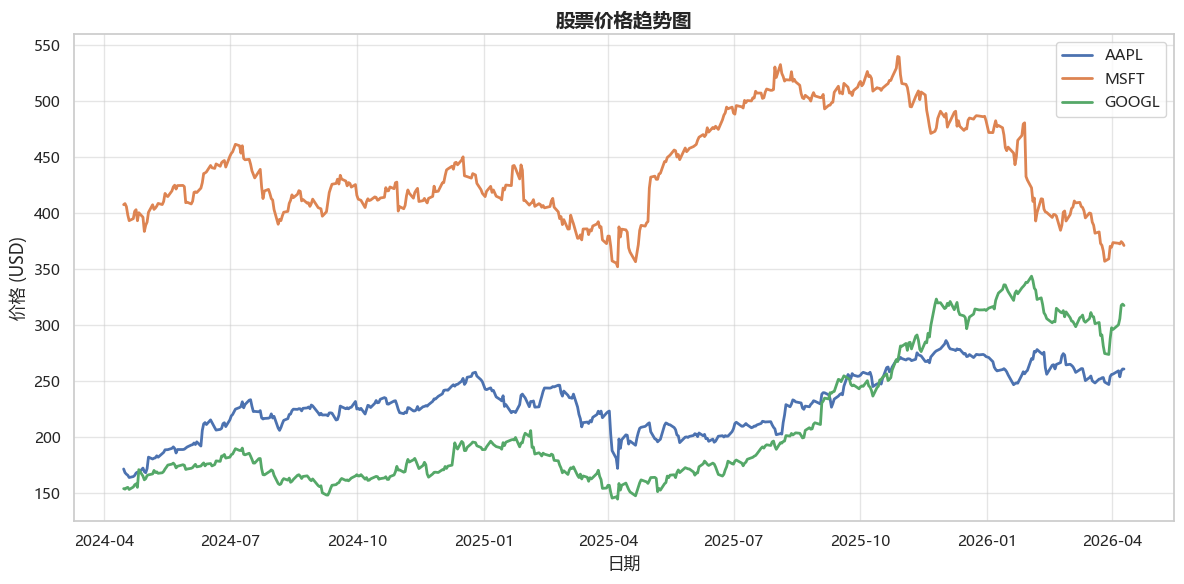

In [49]:
plt.figure(figsize=(12, 6))
for stock in stock_list:
    plt.plot(close_prices.index, close_prices[stock], label=stock, linewidth=2)

plt.title('股票价格趋势图', fontsize=14, fontweight='bold')
plt.xlabel('日期')
plt.ylabel('价格 (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

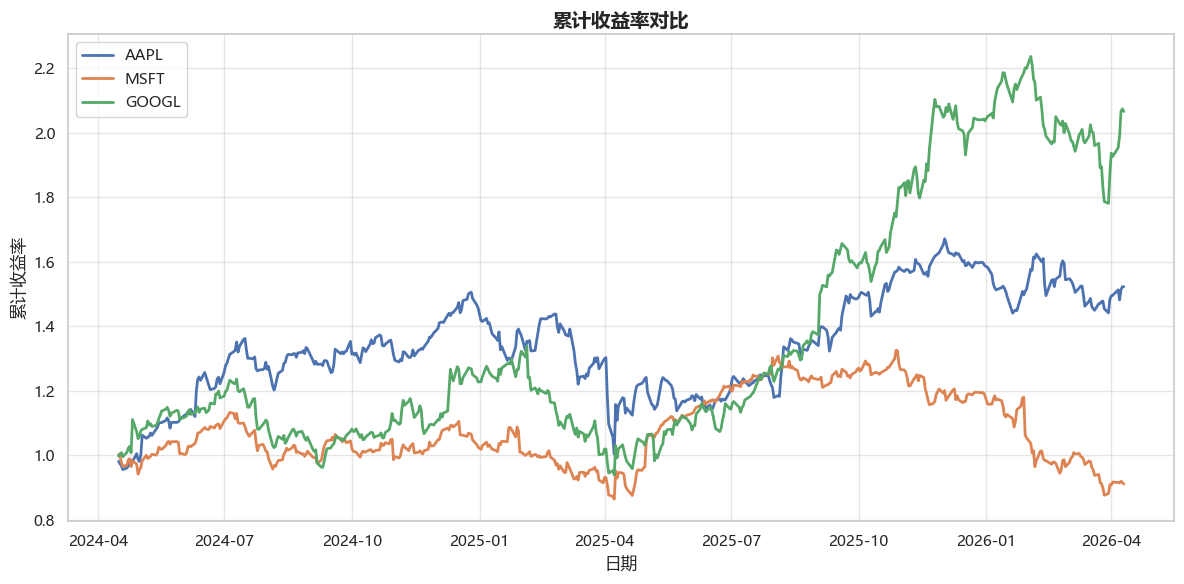

In [50]:
plt.figure(figsize=(12, 6))
for stock in stock_list:
    plt.plot(cumulative_returns.index, cumulative_returns[stock], label=stock, linewidth=2)

plt.title('累计收益率对比', fontsize=14, fontweight='bold')
plt.xlabel('日期')
plt.ylabel('累计收益率')
plt.legend()
plt.tight_layout()
plt.savefig('figures/cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

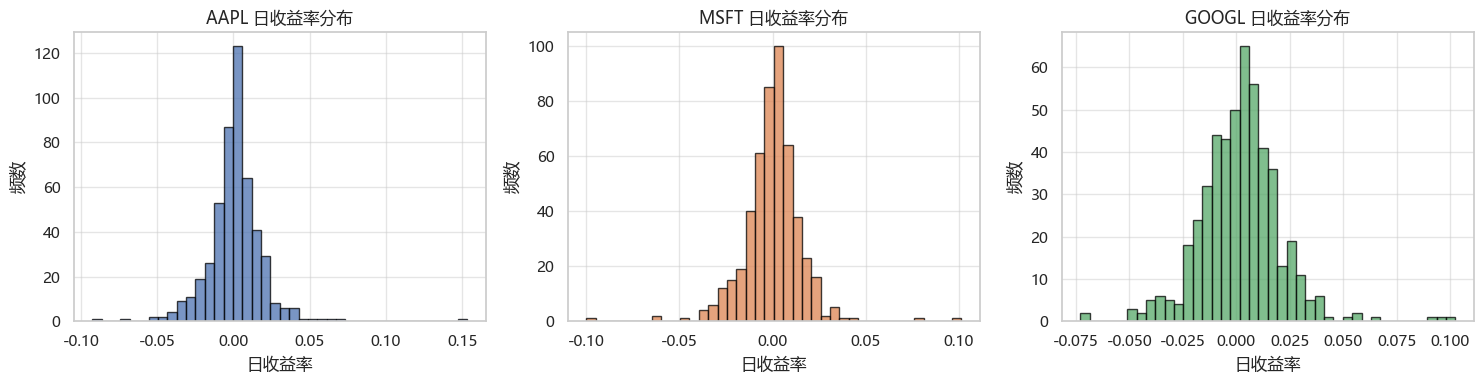

In [51]:
fig, axes = plt.subplots(1, len(stock_list), figsize=(5 * len(stock_list), 4))
if len(stock_list) == 1:
    axes = [axes]

for i, stock in enumerate(stock_list):
    axes[i].hist(returns[stock].dropna(), bins=40, edgecolor='black', alpha=0.75, color=f'C{i}')
    axes[i].set_title(f'{stock} 日收益率分布')
    axes[i].set_xlabel('日收益率')
    axes[i].set_ylabel('频数')

plt.tight_layout()
plt.savefig('figures/returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

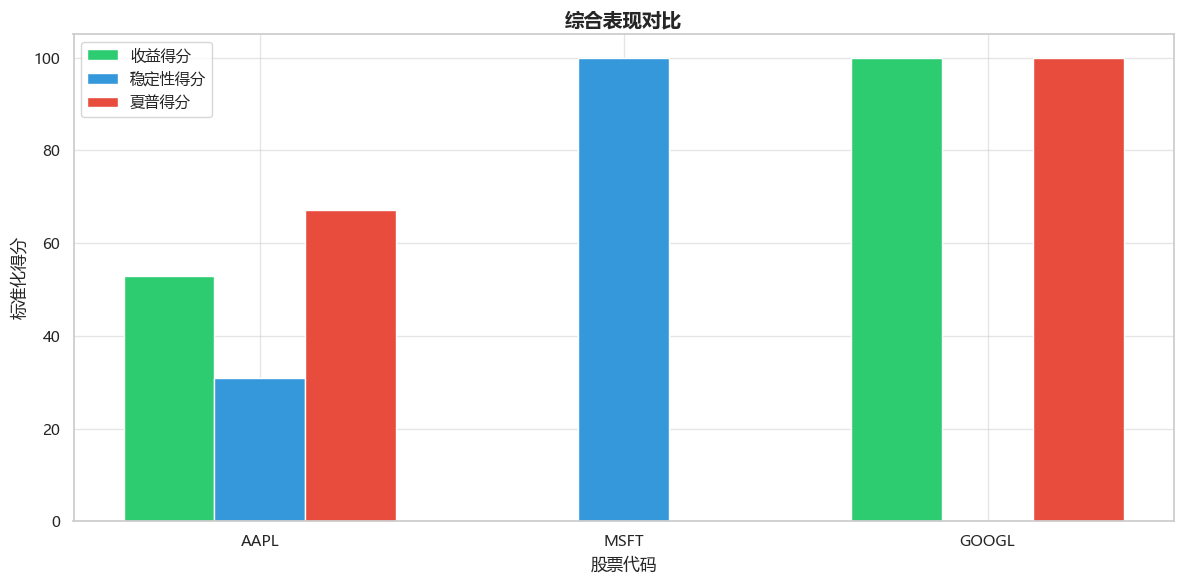

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(stock_list))
width = 0.25

ax.bar(x - width, returns_score.reindex(stock_list), width, label='收益得分', color='#2ecc71')
ax.bar(x, stability_score.reindex(stock_list), width, label='稳定性得分', color='#3498db')
ax.bar(x + width, sharpe_score.reindex(stock_list), width, label='夏普得分', color='#e74c3c')

ax.set_title('综合表现对比', fontsize=14, fontweight='bold')
ax.set_xlabel('股票代码')
ax.set_ylabel('标准化得分')
ax.set_xticks(x)
ax.set_xticklabels(stock_list)
ax.legend()
plt.tight_layout()
plt.savefig('figures/comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. 结果输出与投资洞察

In [53]:
best_performer = total_returns.idxmax()
worst_performer = total_returns.idxmin()
lowest_volatility = annual_volatility.idxmin()
best_sharpe = sharpe_ratios.idxmax()

print('综合财务指标汇总：')
display(summary_df)

print('关键洞察：')
print(f'1. 最佳收益表现: {best_performer} ({total_returns[best_performer]:.2f}%)')
print(f'2. 最低风险股票: {lowest_volatility} (年化波动性 {annual_volatility[lowest_volatility]:.2f}%)')
print(f'3. 最优风险调整收益: {best_sharpe} (夏普比率 {sharpe_ratios[best_sharpe]:.4f})')
print(f'4. 需重点关注股票: {worst_performer} ({total_returns[worst_performer]:.2f}%)')
print('5. 投资建议:')
print(f'   保守型投资者可优先关注 {lowest_volatility}。')
print(f'   成长型投资者可优先关注 {best_performer}。')
print(f'   平衡型投资者可优先关注 {best_sharpe}。')

综合财务指标汇总：


,股票代码,当前价格 (USD),总收益率 (%),年化波动性 (%),夏普比率
0,AAPL,260.48,52.21,28.31,0.8205
1,MSFT,370.87,-8.96,24.13,-0.1590
2,GOOGL,317.24,106.55,30.17,1.3008


关键洞察：
1. 最佳收益表现: GOOGL (106.55%)
2. 最低风险股票: MSFT (年化波动性 24.13%)
3. 最优风险调整收益: GOOGL (夏普比率 1.3008)
4. 需重点关注股票: MSFT (-8.96%)
5. 投资建议:
   保守型投资者可优先关注 MSFT。
   成长型投资者可优先关注 GOOGL。
   平衡型投资者可优先关注 GOOGL。


## 7. 结论


1. 从 Yahoo Finance 下载股票价格数据。
2. 对收盘价序列进行缺失值处理与结构兼容。
3. 计算总收益率、年化波动性与夏普比率。
4. 输出价格趋势、累计收益率、收益率分布与综合比较图。
5. 结合指标生成适合不同风险偏好的投资建议。

数据来源：Yahoo Finance API